
DATASET SHAPE
(10001, 24)

COLUMN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   loan_id                       10001 non-null  object 
 1   customer_id                   10001 non-null  object 
 2   current_loan_amount           10001 non-null  float64
 3   term                          10001 non-null  object 
 4   credit_score                  10001 non-null  float64
 5   annual_income                 10001 non-null  float64
 6   years_in_current_job          10001 non-null  object 
 7   home_ownership                10001 non-null  object 
 8   purpose                       10001 non-null  object 
 9   monthly_debt                  10001 non-null  float64
 10  years_of_credit_history       10001 non-null  float64
 11  months_since_last_delinquent  10001 non-null  float64
 12  number_of_open_accou

C:\Users\muthamilharasi\AppData\Local\Temp\ipykernel_14788\3683232343.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_data['years_in_current_job'].fillna(


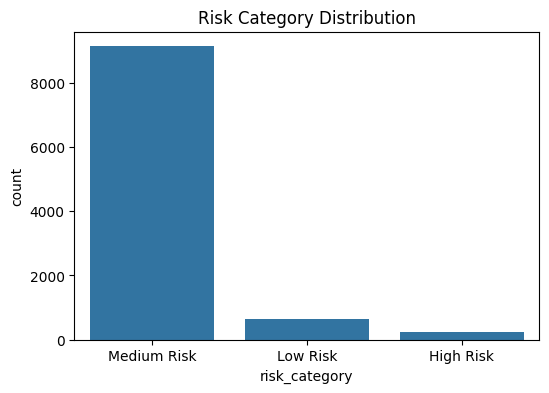


LABEL ENCODING
0 --> High Risk
1 --> Low Risk
2 --> Medium Risk

CHECKING NaN VALUES
0

CHECKING INF VALUES
0

MODEL ACCURACY
0.9950024987506247

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.81      0.89        47
           1       1.00      0.99      1.00       127
           2       0.99      1.00      1.00      1827

    accuracy                           1.00      2001
   macro avg       1.00      0.93      0.96      2001
weighted avg       1.00      1.00      0.99      2001



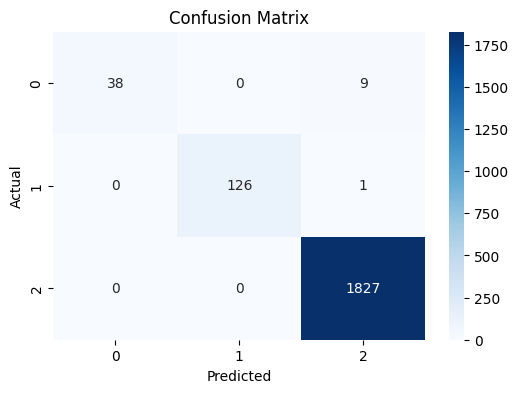


TOP 10 IMPORTANT FEATURES
                Feature  Importance
1          credit_score    0.578304
19      term_Short Term    0.094310
17   credit_utilization    0.031079
13       monthly_income    0.030435
2         annual_income    0.030424
15         emi_estimate    0.030406
0   current_loan_amount    0.030267
10  maximum_open_credit    0.023376
18     debt_per_account    0.018492
4          monthly_debt    0.018412


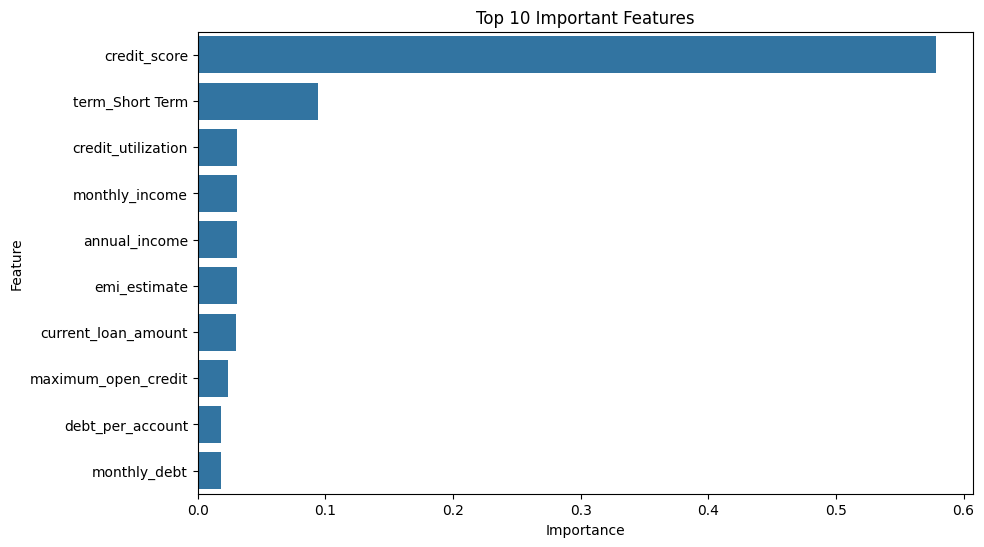


MODEL SAVED SUCCESSFULLY

SAMPLE PREDICTION
Medium Risk

PROJECT COMPLETED SUCCESSFULLY!


In [2]:
# =========================================================
# LOAN RISK PREDICTION PROJECT - FULL FIXED TRAINING CODE
# =========================================================

# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATASET
# =========================

loan_data = pd.read_csv("cleaned_loan_data.csv")

# =========================
# CLEAN COLUMN NAMES
# =========================

loan_data.columns = (
    loan_data.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# =========================
# BASIC DATA INFO
# =========================

print("\n========================")
print("DATASET SHAPE")
print("========================")

print(loan_data.shape)

print("\n========================")
print("COLUMN INFO")
print("========================")

print(loan_data.info())

# =========================
# DROP ID COLUMNS
# =========================

loan_data.drop(
    ['loan_id', 'customer_id'],
    axis=1,
    inplace=True
)

# =========================
# CLEAN years_in_current_job
# =========================

loan_data['years_in_current_job'] = (
    loan_data['years_in_current_job']
    .str.replace('years', '', regex=False)
    .str.replace('year', '', regex=False)
    .str.replace('+', '', regex=False)
    .str.replace('< 1', '0', regex=False)
    .str.strip()
)

loan_data['years_in_current_job'] = pd.to_numeric(
    loan_data['years_in_current_job'],
    errors='coerce'
)

loan_data['years_in_current_job'].fillna(
    loan_data['years_in_current_job'].median(),
    inplace=True
)

# =========================
# FEATURE ENGINEERING
# =========================

loan_data['financial_burden'] = (
    loan_data['monthly_debt']
    /
    loan_data['annual_income']
)

loan_data['credit_utilization'] = (
    loan_data['current_credit_balance']
    /
    loan_data['maximum_open_credit']
)

loan_data['debt_per_account'] = (
    loan_data['monthly_debt']
    /
    loan_data['number_of_open_accounts']
)

# =========================
# HANDLE INF / NaN VALUES
# =========================

loan_data.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

loan_data.fillna(
    loan_data.median(numeric_only=True),
    inplace=True
)

# =========================
# CHECK TARGET DISTRIBUTION
# =========================

print("\n========================")
print("RISK CATEGORY DISTRIBUTION")
print("========================")

print(
    loan_data['risk_category'].value_counts()
)

# =========================
# VISUALIZE TARGET
# =========================

plt.figure(figsize=(6,4))

sns.countplot(
    x='risk_category',
    data=loan_data
)

plt.title("Risk Category Distribution")

plt.show()

# =========================
# ENCODE TARGET VARIABLE
# =========================

le = LabelEncoder()

loan_data['risk_encoded'] = le.fit_transform(
    loan_data['risk_category']
)

# =========================
# SAVE LABEL CLASSES
# =========================

pickle.dump(
    le.classes_,
    open("label_classes.pkl", "wb")
)

print("\n========================")
print("LABEL ENCODING")
print("========================")

for i, label in enumerate(le.classes_):
    print(f"{i} --> {label}")

# =========================
# FEATURES & TARGET
# =========================

X = loan_data.drop(
    ['risk_category', 'risk_encoded'],
    axis=1
)

y = loan_data['risk_encoded']

# =========================
# ONE-HOT ENCODING
# =========================

X = pd.get_dummies(
    X,
    drop_first=True
)

# =========================
# CONVERT TO FLOAT
# =========================

X = X.astype(float)

# =========================
# CHECK NaN VALUES
# =========================

print("\n========================")
print("CHECKING NaN VALUES")
print("========================")

print(X.isnull().sum().sum())

# =========================
# CHECK INF VALUES
# =========================

print("\n========================")
print("CHECKING INF VALUES")
print("========================")

print(np.isinf(X).sum().sum())

# =========================
# SAVE FEATURE COLUMNS
# =========================

model_columns = X.columns

pickle.dump(
    model_columns,
    open("model_columns.pkl", "wb")
)

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# TRAIN RANDOM FOREST MODEL
# =========================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    max_depth=10,
    min_samples_split=5
)

rf_model.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================

pred = rf_model.predict(X_test)

# =========================
# MODEL EVALUATION
# =========================

print("\n========================")
print("MODEL ACCURACY")
print("========================")

print(
    accuracy_score(y_test, pred)
)

print("\n========================")
print("CLASSIFICATION REPORT")
print("========================")

print(
    classification_report(y_test, pred)
)

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# =========================
# FEATURE IMPORTANCE
# =========================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n========================")
print("TOP 10 IMPORTANT FEATURES")
print("========================")

print(importance.head(10))

# =========================
# FEATURE IMPORTANCE PLOT
# =========================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

# =========================
# SAVE MODEL
# =========================

pickle.dump(
    rf_model,
    open("risk_model.pkl", "wb")
)

print("\n========================")
print("MODEL SAVED SUCCESSFULLY")
print("========================")

# =========================
# SAMPLE PREDICTION
# =========================

sample = X_test.iloc[0:1]

prediction = rf_model.predict(sample)

label_classes = pickle.load(
    open("label_classes.pkl", "rb")
)

predicted_label = label_classes[
    prediction[0]
]

print("\n========================")
print("SAMPLE PREDICTION")
print("========================")

print(predicted_label)

print("\nPROJECT COMPLETED SUCCESSFULLY!")